# Analysis of Memory Deterioration Across Blocks and Speed-Accuracy Tradeoff

This notebook tests two hypotheses about the temporal dynamics and cognitive strategies in the sentence memorability task.

---

## Hypothesis 7 (H7): Memory Deterioration Across Blocks (Proactive Interference)

> If previously encoded sentences interfere with the encoding of new sentences, **corrected memorability should decline** monotonically from Block 1 → Block 2 → Block 3 as proactive interference accumulates.

- **DV:** Corrected memorability (Hit Rate − FA Rate) per participant × block
- **IV:** Block (1, 2, 3) — three levels, within-subjects
- **Block extraction:** Blocks are delimited by `Rest Phase started` events in the log data.
- **Normality:** Shapiro-Wilk per block.
- **Test:** **Friedman test** (non-parametric repeated-measures across 3 blocks) + post-hoc **Wilcoxon signed-rank** with **Holm–Bonferroni** correction.

---

## Hypothesis 8 (H8): Speed-Accuracy Tradeoff

> If participants trade response speed for accuracy, participants who respond faster to Wording Recognition (WR) should be **less accurate** on average.
> A negative Spearman correlation between mean WR reaction time and mean WR accuracy would confirm the tradeoff.

- **DV:** Per-participant mean WR accuracy and mean WR reaction time (across all valid repeat trials)
- **IV:** Mean WR reaction time (continuous, across participants)
- **Test:** **Spearman rank correlation** between mean RT and mean WR accuracy (overall + per lexical condition)


In [1]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

# Set visualization style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Define path to log files
log_path = 'NewLogsAnonymized'
log_pattern = os.path.join(log_path, '*.log')

# Find all log files
all_files = glob.glob(log_pattern)
print(f'Found {len(all_files)} log files.')

Found 114 log files.


## Data Loading and Cleaning

The core pipeline is identical to `Hyp1Hyp2.ipynb`. An additional step introduces **block extraction**:

- The experiment contains 3 blocks separated by `Rest Phase started` events.
- For each trial, we count how many rest-phase events preceded it. That count + 1 = block number.
- `np.searchsorted` is used for efficient computation over the sorted rest-phase timestamps.

In [2]:
# Load and concatenate all participant log files
df_list = []

for filename in all_files:
    try:
        df = pd.read_csv(filename, on_bad_lines='skip')
        df_list.append(df)
    except Exception as e:
        print(f'Error reading {filename}: {e}')

if df_list:
    raw_data = pd.concat(df_list, axis=0, ignore_index=True)
    print(f'Successfully loaded {len(raw_data)} rows from {len(df_list)} files.')
else:
    print('No data loaded.')
    raw_data = pd.DataFrame()

# Remove all practice events (Event starts with "Practice")
practice_mask = raw_data['Event'].str.startswith('Practice', na=False)
print(f'Removing {practice_mask.sum()} practice events.')
raw_data = raw_data[~practice_mask].reset_index(drop=True)

print(f'Rows after removing practice events: {len(raw_data)}')
unique_events = raw_data['Event'].unique()
print(f'Unique events: {unique_events}')
raw_data.head()

Successfully loaded 81329 rows from 114 files.
Removing 5269 practice events.
Rows after removing practice events: 76060
Unique events: <ArrowStringArray>
[             'Sentence shown',                    'gap_time',
 'Validation Wrong IR pressed',                  'IR pressed',
                  'WR pressed',       'Validation IR pressed',
          'Rest Phase started',           'Validation Missed']
Length: 8, dtype: str


,participant_ID,Timestamp,Event,Stimulus,isTarget,isValidation,isRepeat,Button,Accuracy IR,Accuracy WR,Reaction_time_IR,Reaction_time_WR,CR_IR,CR_WR
0,232,1770219378184,Sentence shown,HF_29_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,232,1770219382186,gap_time,NaN,NaN,NaN,NaN,GapTime_1289,NaN,NaN,NaN,NaN,NaN,NaN
2,232,1770219383476,Sentence shown,HF_9_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232,1770219387478,gap_time,NaN,NaN,NaN,NaN,GapTime_1108,NaN,NaN,NaN,NaN,NaN,NaN
4,232,1770219388587,Sentence shown,HF_24_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── Parse Stimulus → Core_ID + Voice ───────────────────────────────────────
def parse_stimulus(stim):
    if pd.isna(stim):
        return None, None
    parts = stim.rsplit('_', 1)
    if len(parts) == 2:
        core_id = parts[0]
        voice   = parts[1]  # Expected 'A' or 'P'
        return core_id, voice
    return stim, None

# Apply parsing
raw_data['Core_ID'], raw_data['Voice'] = zip(*raw_data['Stimulus'].apply(parse_stimulus))

# Convert numeric columns
for col in ['Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR']:
    raw_data[col] = pd.to_numeric(raw_data[col], errors='coerce')

# Convert boolean-like columns
for col in ['isTarget', 'isValidation', 'isRepeat']:
    raw_data[col] = raw_data[col].astype(str).str.strip().str.lower() == 'true'

# Sort chronologically per participant
raw_data = raw_data.sort_values(['participant_ID', 'Timestamp']).reset_index(drop=True)

# ── Build trial IDs ────────────────────────────────────────────────────────
raw_data['trial_id'] = raw_data.groupby('participant_ID')['Event'].transform(
    lambda x: (x == 'Sentence shown').cumsum()
)

# ── Extract Block Information BEFORE trial_id > 0 filter ──────────────────
# "Rest Phase started" events mark the boundary between experimental blocks.
# Saving them here ensures we capture any that fall before trial_id > 0.
rest_events = raw_data[
    raw_data['Event'] == 'Rest Phase started'
][['participant_ID', 'Timestamp']].copy()

n_rest_evts = len(rest_events)
n_rest_pids = rest_events['participant_ID'].nunique()
print(f'Rest phase events found: {n_rest_evts} across {n_rest_pids} participants')

# Timestamp of first "Sentence shown" per trial (used for block assignment)
trial_timestamps = (
    raw_data[raw_data['Event'] == 'Sentence shown']
    .groupby(['participant_ID', 'trial_id'])['Timestamp']
    .min()
    .reset_index()
)
trial_timestamps.columns = ['participant_ID', 'trial_id', 'trial_timestamp']

# Assign block number = (# rest phases before this trial) + 1
# np.searchsorted gives the index where trial_timestamp would be inserted in sorted p_rests
# → this equals the count of rest timestamps that are strictly less than trial_timestamp
block_list = []
for pid in trial_timestamps['participant_ID'].unique():
    p_rests  = rest_events[
        rest_events['participant_ID'] == pid
    ]['Timestamp'].sort_values().values
    p_trials = trial_timestamps[trial_timestamps['participant_ID'] == pid].copy()
    p_trials['block'] = p_trials['trial_timestamp'].apply(
        lambda ts: int(np.searchsorted(p_rests, ts, side='right')) + 1
    )
    block_list.append(p_trials[['participant_ID', 'trial_id', 'block']])

block_df = pd.concat(block_list, ignore_index=True)
print(f'\nBlock distribution (all trials, including validation):')
print(block_df['block'].value_counts().sort_index().to_string())

# ── Filter and Build Trials Table ─────────────────────────────────────────
raw_data = raw_data[raw_data['trial_id'] > 0].copy()

# Sentence-shown metadata (one row per trial)
sent_rows = raw_data[raw_data['Event'] == 'Sentence shown'].drop_duplicates(
    subset=['participant_ID', 'trial_id'], keep='first'
)[['participant_ID', 'trial_id', 'Stimulus', 'Core_ID', 'Voice',
   'isTarget', 'isValidation', 'isRepeat']].copy()

# Trial-level aggregates
trial_agg = raw_data.groupby(['participant_ID', 'trial_id']).agg(
    ir_pressed=('Event', lambda x: x.str.contains('IR pressed').any()),
    wr_pressed=('Event', lambda x: x.str.contains('WR pressed').any()),
    has_validation=('Event', lambda x: x.str.contains('Validation').any()),
    ir_accuracy=('Accuracy IR', 'max'),
    wr_accuracy=('Accuracy WR', 'max'),
    ir_rt=('Reaction_time_IR', 'min'),
    wr_rt=('Reaction_time_WR', 'min'),
).reset_index()

# Merge into trial table
trials = sent_rows.merge(trial_agg, on=['participant_ID', 'trial_id'])
trials['is_validation'] = trials['isValidation'] | trials['has_validation']
trials.rename(columns={'isTarget': 'is_target', 'isRepeat': 'is_repeat'}, inplace=True)

# Merge block assignment
trials = trials.merge(block_df, on=['participant_ID', 'trial_id'], how='left')

n_trials       = len(trials)
n_participants = trials['participant_ID'].nunique()
n_validation   = trials['is_validation'].sum()
n_repeat       = trials['is_repeat'].sum()
print(f'\nBuilt {n_trials} trials from {n_participants} participants')
print(f'Validation trials: {n_validation}')
print(f'Repeat trials: {n_repeat}')

Rest phase events found: 228 across 114 participants

Block distribution (all trials, including validation):
block
1    8436
2    8436
3    8436

Built 25308 trials from 114 participants
Validation trials: 5502
Repeat trials: 8892


In [4]:
# ── Participant Exclusion ───────────────────────────────────────────────────
# Criterion: correct_ir > (wrong_ir / 2) + missed_ir  (matching R analysis)
val_trials = trials[trials['is_validation']].copy()

validation_summary = val_trials.groupby('participant_ID').apply(
    lambda g: pd.Series({
        'correct_ir': (g['is_repeat'] & g['ir_pressed']).sum(),
        'wrong_ir':   (~g['is_repeat'] & g['ir_pressed']).sum(),
        'missed_ir':  (g['is_repeat'] & ~g['ir_pressed']).sum(),
    })
).reset_index()
validation_summary['passes'] = (
    validation_summary['correct_ir'] > (validation_summary['wrong_ir'] / 2) + validation_summary['missed_ir']
)

print('Validation summary per participant:')
display(validation_summary)

valid_ids    = validation_summary.loc[validation_summary['passes'], 'participant_ID'].tolist()
excluded_ids = validation_summary.loc[~validation_summary['passes'], 'participant_ID'].tolist()

print(f'\nValidation check:')
print(f'  Participants excluded: {len(excluded_ids)}  {excluded_ids}')
print(f'  Participants kept:     {len(valid_ids)}')

# Keep valid participants
trials_valid = trials[trials['participant_ID'].isin(valid_ids)].copy()

# ── Attach Original Voice ──────────────────────────────────────────────────
first_pres = trials_valid[~trials_valid['is_repeat']].drop_duplicates(
    subset=['participant_ID', 'Core_ID'], keep='first'
)[['participant_ID', 'Core_ID', 'Voice']].rename(columns={'Voice': 'Original_Voice'})

trials_valid = trials_valid.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')

# ── Label groups ──────────────────────────────────────────────────────────
def get_condition(core_id):
    if pd.isna(core_id):
        return 'Other'
    m = re.match(r'^([A-Za-z]+)', str(core_id))
    if m:
        c       = m.group(1).upper()
        mapping = {'HH': 'HH', 'HVL': 'HL', 'LVH': 'LH', 'LVL': 'LL', 'HF': 'Filler'}
        return mapping.get(c, 'Other')
    return 'Other'

trials_valid['label_group'] = trials_valid['Core_ID'].apply(get_condition)

n_tv = len(trials_valid)
print(f'\nValid trials (kept participants): {n_tv}')
print('Block distribution (valid participants, all trial types):')
print(trials_valid['block'].value_counts().sort_index().to_string())

Validation summary per participant:


,participant_ID,correct_ir,wrong_ir,missed_ir,passes
0,232,30,16,0,True
1,235,29,22,1,True
2,236,30,15,0,True
3,241,29,24,1,True
4,242,27,3,3,True
...,...,...,...,...,...
109,392,29,26,1,True
110,395,28,13,2,True
111,396,30,6,0,True
112,397,30,6,0,True



Validation check:
  Participants excluded: 2  [271, 299]
  Participants kept:     112

Valid trials (kept participants): 24864
Block distribution (valid participants, all trial types):
block
1    8288
2    8288
3    8288


---
## Hypothesis 7: Memory Deterioration Across 3 Blocks (Proactive Interference)

**H₀:** Corrected memorability does *not* change significantly across experimental blocks.  
**H₁:** Corrected memorability decreases from Block 1 to Block 3, reflecting accumulating proactive interference.

- **DV:** Corrected memorability per participant per block (averaged over all target conditions and both voices)
- **IV:** Block (1, 2, 3) — within-subjects, 3 levels
- **Test:** **Friedman test** → post-hoc **Wilcoxon** with **Holm–Bonferroni** if significant

In [5]:
# ── H7: Block-level corrected memorability ─────────────────────────────────
# Use only non-validation, target condition trials
expected_blocks = [1, 2, 3]

target_h7 = trials_valid[
    ~trials_valid['is_validation'] &
    trials_valid['label_group'].isin(['HH', 'HL', 'LH', 'LL']) &
    trials_valid['Voice'].isin(['A', 'P']) &
    trials_valid['block'].isin(expected_blocks)
].copy()

# Compute corrected memorability per participant × block
block_mem = (
    target_h7
    .groupby(['participant_ID', 'block'])
    .apply(lambda g: pd.Series({
        'n_old':        g['is_repeat'].sum(),
        'n_new':        (~g['is_repeat']).sum(),
        'hits':         (g['is_repeat'] & g['ir_pressed']).sum(),
        'false_alarms': (~g['is_repeat'] & g['ir_pressed']).sum(),
    }))
    .reset_index()
)
block_mem['hit_rate'] = np.where(
    block_mem['n_old'] > 0,
    block_mem['hits'] / block_mem['n_old'], np.nan
)
block_mem['fa_rate'] = np.where(
    block_mem['n_new'] > 0,
    block_mem['false_alarms'] / block_mem['n_new'], np.nan
)
block_mem['corrected_memorability'] = block_mem['hit_rate'] - block_mem['fa_rate']

# Pivot to wide format: one column per block
block_pivot = block_mem.pivot(
    index='participant_ID', columns='block', values='corrected_memorability'
)
block_pivot = block_pivot[[b for b in expected_blocks if b in block_pivot.columns]].dropna()
block_pivot.columns = [f'Block{int(b)}' for b in block_pivot.columns]

n_complete = len(block_pivot)
print(f'Participants with complete data for all 3 blocks: {n_complete}')

print('\n=== H7 Descriptive Statistics: Corrected Memorability per Block ===')
desc_blocks = block_pivot.describe().T[['count', 'mean', '50%', 'std', 'min', 'max']]
desc_blocks.columns = ['N', 'Mean', 'Median', 'SD', 'Min', 'Max']
display(desc_blocks.round(3))

# Trend check
means = [block_pivot[col].mean() for col in block_pivot.columns]
print(f'\nBlock means: {" → ".join([f"{m:.3f}" for m in means])}')
if means[0] > means[-1]:
    print('Descriptive trend: DECREASE (consistent with proactive interference)')
else:
    print('Descriptive trend: INCREASE (inconsistent with proactive interference)')

Participants with complete data for all 3 blocks: 112

=== H7 Descriptive Statistics: Corrected Memorability per Block ===


,N,Mean,Median,SD,Min,Max
Block1,112.0,0.855,0.875,0.138,0.250,1.0
Block2,112.0,0.835,0.875,0.181,0.062,1.0
Block3,112.0,0.809,0.875,0.185,0.250,1.0



Block means: 0.855 → 0.835 → 0.809
Descriptive trend: DECREASE (consistent with proactive interference)


In [6]:
# ── Shapiro-Wilk normality test per block ─────────────────────────────────
print('=== Shapiro-Wilk Normality Test (H7, per Block) ===')
sw_rows = []
for col in block_pivot.columns:
    w, p = stats.shapiro(block_pivot[col])
    sw_rows.append({
        'Block':   col,
        'W':       round(w, 4),
        'p-value': '< 0.001' if p < 0.001 else round(p, 4),
        'Normal':  'Yes' if p >= 0.05 else 'No'
    })
display(pd.DataFrame(sw_rows))

# ── Friedman test (non-parametric repeated-measures ANOVA across 3 blocks) ─
block_arrays          = [block_pivot[col].values for col in block_pivot.columns]
friedman_stat7, friedman_p7 = stats.friedmanchisquare(*block_arrays)
p7_label              = '< 0.001' if friedman_p7 < 0.001 else round(friedman_p7, 4)
dof7                  = len(block_pivot.columns) - 1

print(f'\n=== Friedman Test: Corrected Memorability Across 3 Blocks ===')
print(f'χ²({dof7}) = {friedman_stat7:.4f},  p = {p7_label}')
if friedman_p7 < 0.05:
    trend = 'decreases' if means[0] > means[-1] else 'increases'
    print(f'Result: SIGNIFICANT — Memory performance {trend} significantly across blocks.')
    if means[0] > means[-1]:
        print('Interpretation: Proactive interference accumulates across the experiment.')
    else:
        print('Interpretation: Unexpected improvement — possible practice or warm-up effect.')
    print('Proceeding to post-hoc pairwise tests...')
else:
    print('Result: NOT SIGNIFICANT — No significant change in memorability across blocks.')
    print('Interpretation: Proactive interference does not detectably impair recognition over 3 blocks.')

# ── Post-hoc Wilcoxon signed-rank with Holm-Bonferroni ────────────────────
block_cols  = list(block_pivot.columns)
block_pairs = list(combinations(block_cols, 2))
posthoc_rows7 = []

for b1, b2 in block_pairs:
    w_s, p_r = stats.wilcoxon(block_pivot[b1], block_pivot[b2])
    posthoc_rows7.append({
        'Pair':    f'{b1} vs {b2}',
        'W':       round(w_s, 4),
        'p_raw':   round(p_r, 4),
        'Mean_B1': round(block_pivot[b1].mean(), 4),
        'Mean_B2': round(block_pivot[b2].mean(), 4),
    })

posthoc_df7 = pd.DataFrame(posthoc_rows7).sort_values('p_raw').reset_index(drop=True)
n_tests7    = len(posthoc_df7)
p_holm7     = [
    min(1.0, posthoc_df7['p_raw'].iloc[i] * (n_tests7 - i))
    for i in range(n_tests7)
]
posthoc_df7['p_holm']      = [round(p, 4) for p in p_holm7]
posthoc_df7['Significant'] = posthoc_df7['p_holm'] < 0.05

print('\n=== Post-hoc Pairwise Wilcoxon (Blocks) with Holm–Bonferroni Correction ===')
display(posthoc_df7)

=== Shapiro-Wilk Normality Test (H7, per Block) ===


,Block,W,p-value,Normal
0,Block1,0.8506,< 0.001,No
1,Block2,0.8018,< 0.001,No
2,Block3,0.8601,< 0.001,No



=== Friedman Test: Corrected Memorability Across 3 Blocks ===
χ²(2) = 6.2541,  p = 0.0438
Result: SIGNIFICANT — Memory performance decreases significantly across blocks.
Interpretation: Proactive interference accumulates across the experiment.
Proceeding to post-hoc pairwise tests...

=== Post-hoc Pairwise Wilcoxon (Blocks) with Holm–Bonferroni Correction ===


,Pair,W,p_raw,Mean_B1,Mean_B2,p_holm,Significant
0,Block1 vs Block3,1368.0,0.0056,0.8549,0.8092,0.0168,True
1,Block2 vs Block3,1619.0,0.0802,0.8348,0.8092,0.1604,False
2,Block1 vs Block2,1306.0,0.2370,0.8549,0.8348,0.2370,False


C:\Users\Shubh\AppData\Local\Temp\ipykernel_4592\3612047021.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


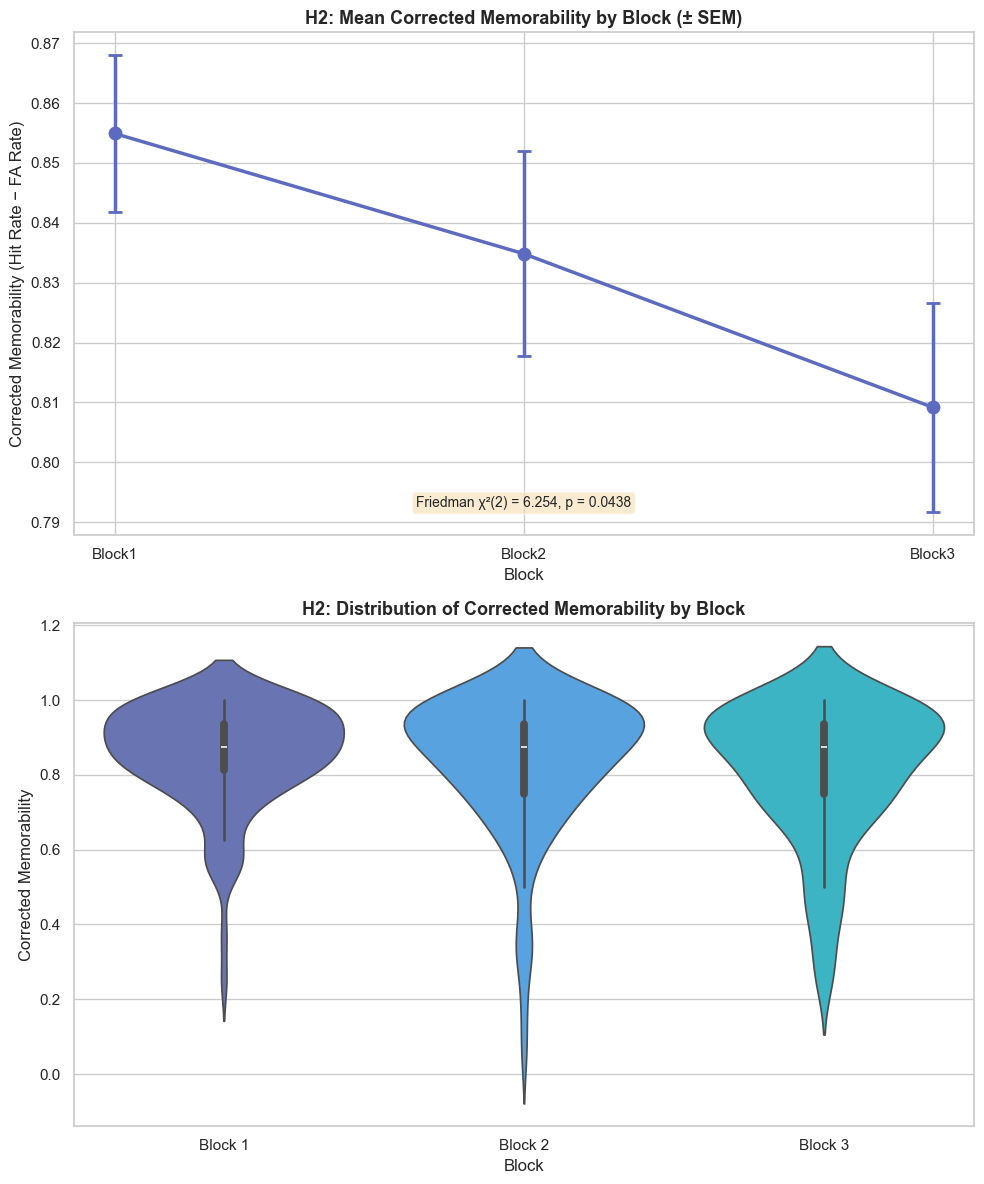

In [16]:
# ── H7 Visualization (Stacked) ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# 1. Line plot: mean corrected memorability ± SEM by block
block_means  = block_pivot.mean()
block_sems   = block_pivot.sem()
x_ticks      = list(range(len(block_pivot.columns)))
block_labels = block_pivot.columns.tolist()

axes[0].errorbar(
    x=x_ticks, y=block_means.values,
    yerr=block_sems.values,
    fmt='-o', color='#5C6BC0', linewidth=2.5, markersize=9, capsize=5, capthick=2
)
axes[0].set_xticks(x_ticks)
axes[0].set_xticklabels(block_labels)
axes[0].set_title('H2: Mean Corrected Memorability by Block (± SEM)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Block')
axes[0].set_ylabel('Corrected Memorability (Hit Rate − FA Rate)')

p7_text = '< 0.001' if friedman_p7 < 0.001 else f'{friedman_p7:.4f}'
axes[0].text(
    0.5, 0.05,
    f'Friedman χ²({dof7}) = {friedman_stat7:.3f}, p = {p7_text}',
    transform=axes[0].transAxes, ha='center', va='bottom', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6)
)

# 2. Violin plot: distribution across blocks
block_long = block_mem[
    block_mem['block'].isin(expected_blocks) &
    block_mem['participant_ID'].isin(valid_ids)
].copy()
block_long['Block'] = block_long['block'].apply(lambda b: f'Block {int(b)}')
block_order = [f'Block {b}' for b in expected_blocks]

sns.violinplot(
    data=block_long, x='Block', y='corrected_memorability',
    order=block_order,
    palette=['#5C6BC0', '#42A5F5', '#26C6DA'],
    inner='box', ax=axes[1]
)
axes[1].set_title('H2: Distribution of Corrected Memorability by Block', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Block')
axes[1].set_ylabel('Corrected Memorability')

plt.tight_layout()
plt.show()


---
## Hypothesis 8: Speed-Accuracy Tradeoff in Wording Recognition

**H₀:** No significant correlation between WR reaction time and WR accuracy.  
**H₁:** A *negative* Spearman correlation between mean WR RT and mean WR accuracy — faster responders are less accurate (classicspeed-accuracy tradeoff).

- **Analysis:** Across N=112 participants, compute mean WR RT and mean WR accuracy (on valid repeat trials). Test Spearman r overall and per lexical condition.
- **Rationale:** If the correlation is *positive*, faster responses reflect an efficiency advantage (no tradeoff). If *negative*, participants are sacrificing accuracy for speed.

In [8]:
# ── H8: Speed-Accuracy Tradeoff ────────────────────────────────────────────
# WR repeat trials: non-validation, target condition, wr was pressed
wr_trials = trials_valid[
    trials_valid['is_repeat'] &
    trials_valid['wr_pressed'] &
    ~trials_valid['is_validation'] &
    trials_valid['label_group'].isin(['HH', 'HL', 'LH', 'LL'])
].copy()

# Per participant: mean WR accuracy and mean WR RT (all target conditions pooled)
h8_overall = wr_trials.groupby('participant_ID').agg(
    mean_accuracy=('wr_accuracy', 'mean'),
    mean_rt=('wr_rt', 'mean')
).dropna().reset_index()

n_h8 = len(h8_overall)
print(f'Participants with complete WR data: {n_h8}')

print('\n=== H8 Descriptive Statistics ===')
acc_mean = h8_overall['mean_accuracy'].mean()
acc_sd   = h8_overall['mean_accuracy'].std()
rt_mean  = h8_overall['mean_rt'].mean()
rt_sd    = h8_overall['mean_rt'].std()
print(f'Mean WR Accuracy:       {acc_mean:.4f}  (SD = {acc_sd:.4f})')
print(f'Mean WR Reaction Time:  {rt_mean:.2f} ms  (SD = {rt_sd:.2f} ms)')

# ── Overall Spearman r ────────────────────────────────────────────────────
r_s_all, p_s_all = stats.spearmanr(h8_overall['mean_rt'], h8_overall['mean_accuracy'])
p_all_label      = '< 0.001' if p_s_all < 0.001 else round(p_s_all, 4)

print(f'\n=== Spearman Correlation: WR RT vs. WR Accuracy (Overall) ===')
print(f'r_s = {r_s_all:.4f},  p = {p_all_label}')

if p_s_all < 0.05:
    if r_s_all < 0:
        print('Result: SIGNIFICANT NEGATIVE correlation')
        print('Interpretation: Faster responders tend to be LESS accurate — speed-accuracy tradeoff confirmed.')
    else:
        print('Result: SIGNIFICANT POSITIVE correlation')
        print('Interpretation: Faster responders are MORE accurate — no classic tradeoff (efficiency advantage).')
else:
    print('Result: NOT SIGNIFICANT — No significant speed-accuracy tradeoff overall.')
    print('Interpretation: WR reaction time and WR accuracy are independent across participants.')

# ── Spearman r by lexical condition ───────────────────────────────────────
print('\n=== Spearman Correlation by Lexical Condition ===')
cond_spearman = []
for cond in ['HH', 'HL', 'LH', 'LL']:
    sub_trials = wr_trials[wr_trials['label_group'] == cond]
    sub_agg    = sub_trials.groupby('participant_ID').agg(
        mean_accuracy=('wr_accuracy', 'mean'),
        mean_rt=('wr_rt', 'mean')
    ).dropna()
    if len(sub_agg) < 5:
        print(f'{cond}: Insufficient data (n={len(sub_agg)}), skipping.')
        continue
    r_c, p_c  = stats.spearmanr(sub_agg['mean_rt'], sub_agg['mean_accuracy'])
    p_c_label = '< 0.001' if p_c < 0.001 else round(p_c, 4)
    sig       = '(*)' if p_c < 0.05 else ''
    cond_spearman.append({
        'Condition':   cond,
        'n':           len(sub_agg),
        'r_s':         round(r_c, 4),
        'p-value':     p_c_label,
        'Significant': p_c < 0.05
    })
    print(f'{cond}: r_s = {r_c:.4f},  p = {p_c_label}  {sig}')

print()
display(pd.DataFrame(cond_spearman))

Participants with complete WR data: 112

=== H8 Descriptive Statistics ===
Mean WR Accuracy:       0.7485  (SD = 0.0982)
Mean WR Reaction Time:  1061.29 ms  (SD = 515.84 ms)

=== Spearman Correlation: WR RT vs. WR Accuracy (Overall) ===
r_s = 0.1406,  p = 0.1393
Result: NOT SIGNIFICANT — No significant speed-accuracy tradeoff overall.
Interpretation: WR reaction time and WR accuracy are independent across participants.

=== Spearman Correlation by Lexical Condition ===
HH: r_s = 0.1001,  p = 0.2937  
HL: r_s = 0.0551,  p = 0.564  
LH: r_s = -0.0505,  p = 0.5969  
LL: r_s = 0.1804,  p = 0.057  



,Condition,n,r_s,p-value,Significant
0,HH,112,0.1001,0.2937,False
1,HL,112,0.0551,0.5640,False
2,LH,112,-0.0505,0.5969,False
3,LL,112,0.1804,0.0570,False


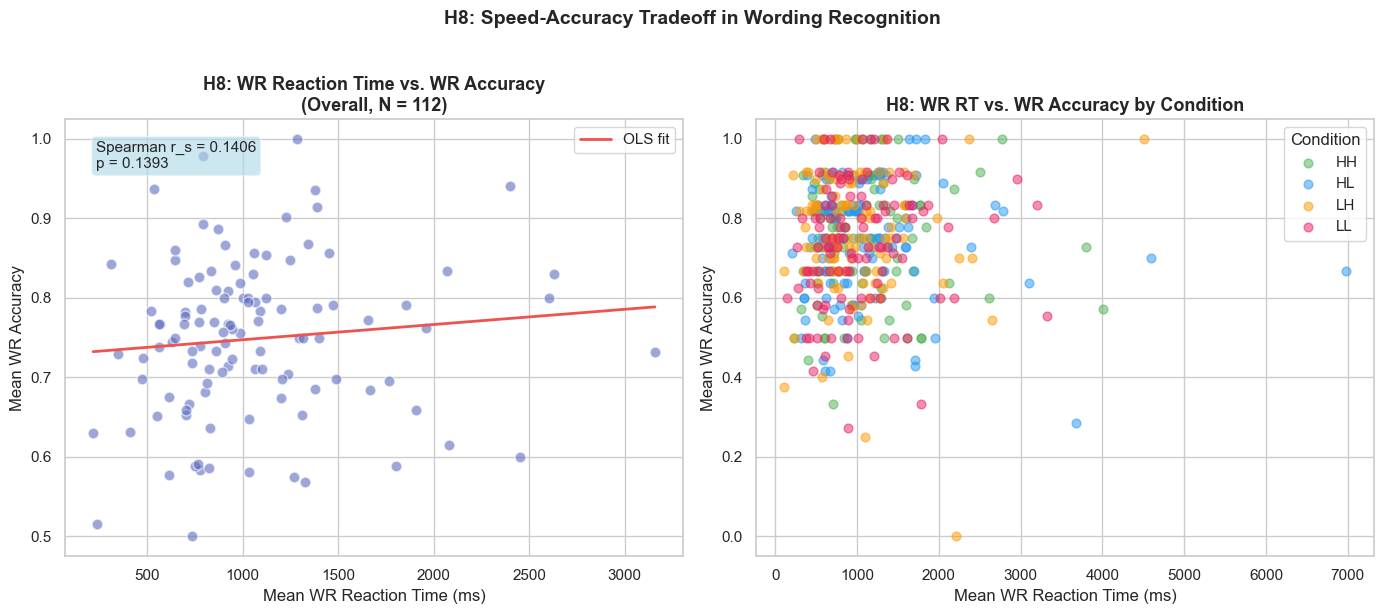

In [9]:
# ── H8 Visualization ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: overall RT vs. WR accuracy with OLS fit line
axes[0].scatter(
    h8_overall['mean_rt'], h8_overall['mean_accuracy'],
    alpha=0.6, color='#5C6BC0', edgecolors='white', s=60, zorder=3
)
m, b    = np.polyfit(h8_overall['mean_rt'], h8_overall['mean_accuracy'], 1)
x_line  = np.linspace(h8_overall['mean_rt'].min(), h8_overall['mean_rt'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='#EF5350', linewidth=2, label='OLS fit', zorder=4)
axes[0].set_title(
    f'H8: WR Reaction Time vs. WR Accuracy\n(Overall, N = {n_h8})',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Mean WR Reaction Time (ms)')
axes[0].set_ylabel('Mean WR Accuracy')
p_annot_h8 = '< 0.001' if p_s_all < 0.001 else f'{p_s_all:.4f}'
axes[0].text(
    0.05, 0.95,
    f'Spearman r_s = {r_s_all:.4f}\np = {p_annot_h8}',
    transform=axes[0].transAxes, ha='left', va='top', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6)
)
axes[0].legend()

# Scatter: by lexical condition (colour-coded)
cond_colors = {'HH': '#4CAF50', 'HL': '#2196F3', 'LH': '#FF9800', 'LL': '#E91E63'}
for cond in ['HH', 'HL', 'LH', 'LL']:
    sub_trials = wr_trials[wr_trials['label_group'] == cond]
    sub_agg    = sub_trials.groupby('participant_ID').agg(
        mean_accuracy=('wr_accuracy', 'mean'),
        mean_rt=('wr_rt', 'mean')
    ).dropna()
    axes[1].scatter(
        sub_agg['mean_rt'], sub_agg['mean_accuracy'],
        alpha=0.5, color=cond_colors[cond], label=cond, s=40
    )

axes[1].set_title('H8: WR RT vs. WR Accuracy by Condition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean WR Reaction Time (ms)')
axes[1].set_ylabel('Mean WR Accuracy')
axes[1].legend(title='Condition', framealpha=0.8)

plt.suptitle(
    'H8: Speed-Accuracy Tradeoff in Wording Recognition',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Summary & Conclusions: Hypotheses 7 & 8

### Hypothesis 7: Memory Deterioration Across Blocks (Proactive Interference)

**Result: Supported — Corrected memorability declines significantly across blocks (Friedman χ²(2) = 6.25, p = 0.044)**

#### Descriptive Statistics — Corrected Memorability per Block

| Block | N | Mean | Median | SD | Min | Max |
|-------|:-:|:----:|:------:|:--:|:---:|:---:|
| Block 1 | 112 | 0.855 | 0.875 | 0.138 | 0.250 | 1.000 |
| Block 2 | 112 | 0.835 | 0.875 | 0.181 | 0.062 | 1.000 |
| Block 3 | 112 | 0.809 | 0.875 | 0.185 | 0.250 | 1.000 |

All three blocks violated normality (Shapiro-Wilk W ≈ 0.80–0.86, all p < 0.001), so the non-parametric Friedman test was used. The overall test was significant (χ²(2) = 6.25, p = 0.044).

#### Post-hoc Wilcoxon Tests (Holm-Bonferroni corrected)

| Pair | W | p (raw) | p (Holm) | Significant |
|------|:-:|:-------:|:--------:|:-----------:|
| Block 1 vs Block 3 | 1368.0 | 0.0056 | 0.0168 | ✓ |
| Block 2 vs Block 3 | 1619.0 | 0.0802 | 0.1604 | ✗ |
| Block 1 vs Block 2 | 1306.0 | 0.2370 | 0.2370 | ✗ |

The significant contrast is exclusively between **Block 1 and Block 3** (p_holm = 0.017), with a monotonic mean decline of ~0.046 corrected memorability units (0.855 → 0.835 → 0.809) across the three blocks. Adjacent-block differences (1 vs. 2; 2 vs. 3) do not individually reach significance after correction, consistent with a gradual, cumulative interference effect rather than a sharp single drop.

**Interpretation:** The data provide evidence for **proactive interference accumulating over the course of the experiment**. Sentences studied early in the session (Block 1) are significantly better recognised than those studied late (Block 3). The effect is modest in absolute size (~5 percentage points) but statistically reliable, consistent with the classic proactive interference account in episodic memory: previously encoded items compete with the retrieval of later-encoded ones. The absence of a significant Block 1 → Block 2 step suggests the interference effect becomes detectable only after sufficient accumulation.

---

### Hypothesis 8: Speed-Accuracy Tradeoff in Wording Recognition

**Result: Not Supported — No significant correlation between WR RT and WR accuracy (r_s = 0.141, p = 0.139)**

#### Descriptive Statistics

| Measure | Mean | SD |
|---------|:----:|:--:|
| WR Accuracy | 0.749 | 0.098 |
| WR Reaction Time | 1061 ms | 516 ms |

#### Spearman Correlations (Overall + by Condition, N = 112)

| Condition | r_s | p-value | Significant |
|-----------|:---:|:-------:|:-----------:|
| Overall | 0.141 | 0.139 | ✗ |
| HH | 0.100 | 0.294 | ✗ |
| HL | 0.055 | 0.564 | ✗ |
| LH | -0.051 | 0.597 | ✗ |
| LL | 0.180 | 0.057 | ✗ |

No significant Spearman correlation between mean WR reaction time and mean WR accuracy was found — either overall or within any individual lexical condition. The direction of the overall correlation is positive (r_s = 0.14), meaning that, if anything, slower responders tend to be *marginally* more accurate — the opposite of a speed-accuracy tradeoff — but this trend is not reliable.

**Interpretation:** The null hypothesis **cannot be rejected**. Participants who responded faster on the Wording Recognition task were not systematically less accurate, and vice versa. This is consistent with two non-exclusive explanations: (1) WR performance is predominantly determined by **item-level difficulty** (i.e., whether the sentence is memory-distinct) rather than a global speed-versus-accuracy strategy, and (2) the response window design may already encourage a relatively uniform decision threshold across all participants, masking individual tradeoff preferences. The LL condition showed the largest (though non-significant) positive r_s = 0.18, tentatively suggesting that slowing provides a small accuracy benefit specifically for the hardest-to-remember sentences, but this remains speculative.

---

### Cross-Hypothesis Synthesis (H7 & H8)

The two hypotheses together paint a coherent picture of the **temporal and strategic dynamics** of sentence memory in this paradigm:

- **H7** confirms that the memory system is susceptible to proactive interference: recognition accuracy degrades as the session progresses, and the cumulative load of previously heard sentences impairs later encoding. This has practical implications for experiment design — block order and list length are confounds that must be controlled.
- **H8** suggests that, despite this temporal degradation, participants do not compensate with a deliberate speed-vs-accuracy tradeoff. Response speed and accuracy are essentially independent, implying that WR accuracy reflects the quality of the internal memory trace rather than a post-perceptual decisional strategy.

Together, these findings suggest that sentence memorability in this paradigm is **largely stimulus-driven** (governed by item properties and interference history) rather than **strategy-driven** (governed by voluntary response criterion adjustments).